#****Modelos No Supervisados para Detección de Perfiles Falsos****

# 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.ensemble import IsolationForest

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 2. Carga de datos

In [2]:
# Cargar dataset procesado

df = pd.read_csv('twitter_profiles_cleaned.csv')

# Visualizar primeras filas
print(df.head())

           name      screen_name  followers_count  friends_count  post_count  \
0           早川援         0918Bask            286.0          441.0      3431.0   
1          ローラー         1120Roll            351.0          554.0      6179.0   
2  Kelsey Brown      keke_brooke            241.0          197.0      1874.0   
3           bio       pinkfunkys           2164.0          947.0    263152.0   
4      Ms Kathy  191a5bd05da04dc             23.0           96.0       140.0   

  lang    location  default_profile_image  profile_use_background_image  \
0   ja         NaN                  False                         False   
1   ja      大正義横浜市                  False                         False   
2   en         NaN                  False                          True   
3   en         NaN                  False                          True   
4   en  Wichita KS                  False                          True   

   verified                                        description  \
0 

# 3. Selección de variables numéricas

In [3]:
# Seleccionar únicamente columnas numéricas

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

X = df[numerical_columns]

print(X.head())

   followers_count  friends_count  post_count  label  has_location
0            286.0          441.0      3431.0      0             0
1            351.0          554.0      6179.0      0             1
2            241.0          197.0      1874.0      0             0
3           2164.0          947.0    263152.0      0             0
4             23.0           96.0       140.0      0             1


# 4. Limpieza de datos

In [4]:
# Reemplazar valores infinitos

X = X.replace([np.inf, -np.inf], np.nan)

# Eliminar valores nulos

X = X.dropna()

print(X.shape)

(7689, 5)


# 5. Escalamiento de variables

In [5]:
# Escalar datos para algoritmos no supervisados

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 6. Reducción de dimensionalidad con PCA

In [6]:
# Reducir dimensiones para visualización

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(7689, 2)


# 7. KMeans Clustering

Justificación

KMeans permite identificar agrupaciones naturales de perfiles dentro del dataset. Esto ayuda a detectar patrones de comportamiento similares entre usuarios legítimos y perfiles potencialmente falsos.

#7.1 Método del codo

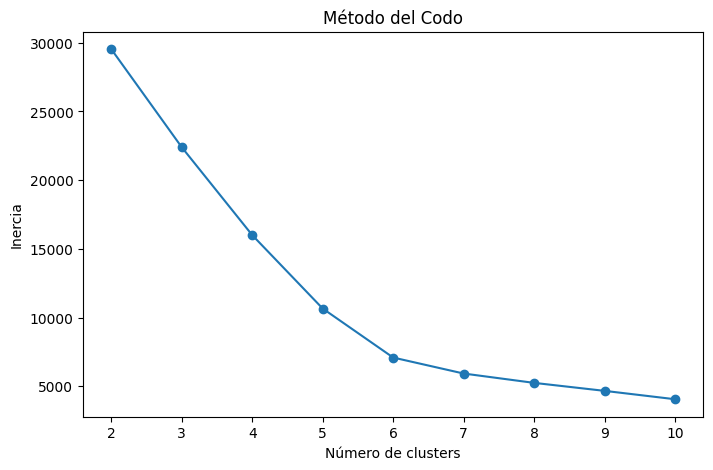

In [7]:
inertia = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)


plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

#7.2 Entrenamiento KMeans

In [8]:
# Entrenar modelo KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Agregar clusters al dataframe

df_kmeans = X.copy()
df_kmeans['cluster'] = clusters

print(df_kmeans['cluster'].value_counts())

cluster
1    5038
0    2649
2       2
Name: count, dtype: int64


#7.3 Evaluación con Silhouette Score

In [9]:
score = silhouette_score(X_scaled, clusters)

print(f'Silhouette Score: {score:.4f}')

Silhouette Score: 0.5071


#7.4 Visualización de clusters

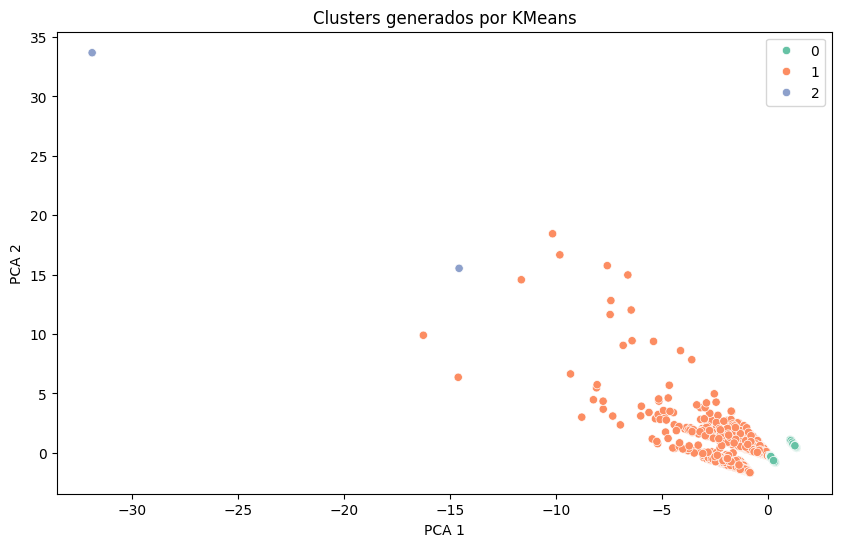

In [10]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette='Set2'
)

plt.title('Clusters generados por KMeans')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

# 8. DBSCAN

##Justificación

DBSCAN permite detectar agrupaciones densas y también identificar ruido o puntos aislados. En problemas de detección de perfiles falsos, los perfiles anómalos suelen aparecer como ruido.

# 8.1 Entrenamiento DBSCAN

In [11]:
#Entrenar DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

clusters_dbscan = dbscan.fit_predict(X_scaled)

# Agregar resultados

df_dbscan = X.copy()
df_dbscan['cluster'] = clusters_dbscan

print(df_dbscan['cluster'].value_counts())

cluster
 1    3387
 2    2504
 0    1610
 3     145
-1      43
Name: count, dtype: int64


#8.2 Visualización DBSCAN

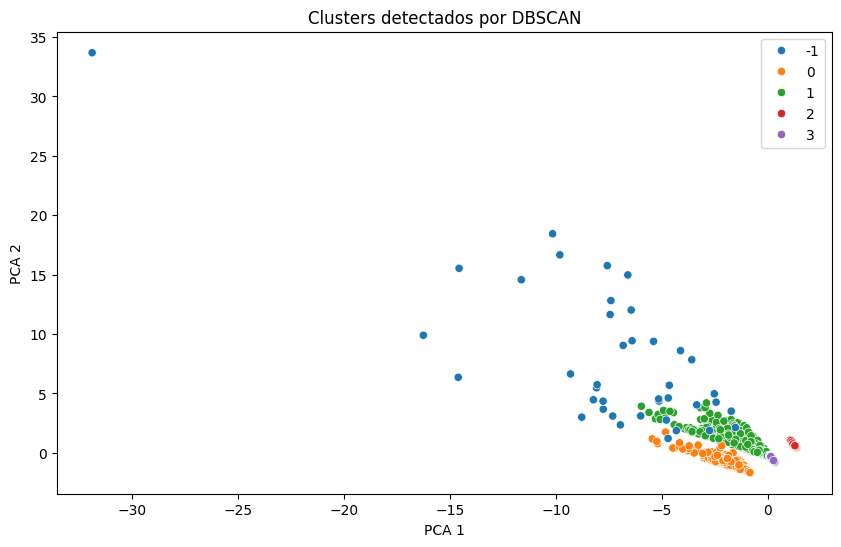

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_dbscan,
    palette='tab10'
)

plt.title('Clusters detectados por DBSCAN')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

#9. Isolation Forest

##Justificación

Isolation Forest es un algoritmo de detección de anomalías altamente utilizado para identificar comportamientos atípicos.

En este proyecto se utiliza debido a que los perfiles falsos pueden presentar patrones diferentes al comportamiento normal de usuarios legítimos.

#9.1 Entrenamiento Isolation Forest

In [13]:
# Entrenar Isolation Forest

isolation_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)

anomalies = isolation_forest.fit_predict(X_scaled)

# Convertir:
# -1 -> anomalía
#  1 -> normal

anomaly_labels = np.where(anomalies == -1, 1, 0)

# Agregar resultados

df_isolation = X.copy()
df_isolation['anomaly'] = anomaly_labels

print(df_isolation['anomaly'].value_counts())

anomaly
0    7304
1     385
Name: count, dtype: int64


#9.2 Visualización de anomalías

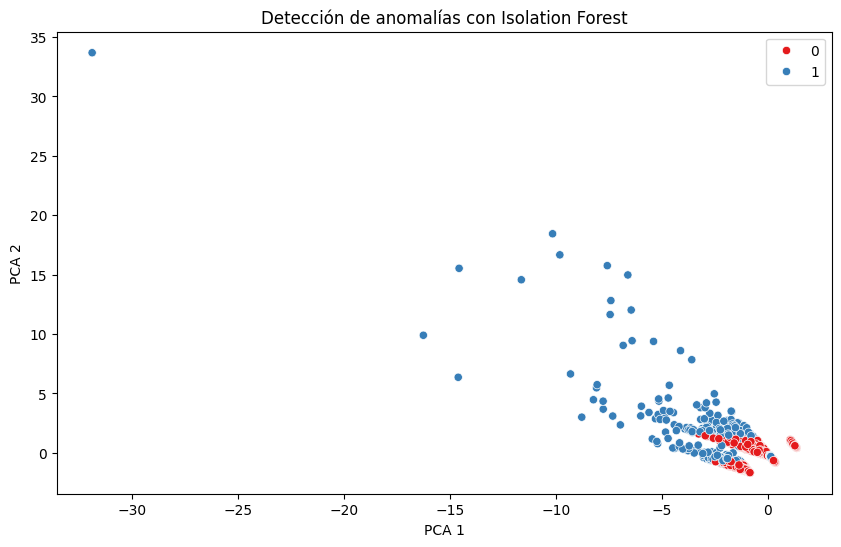

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=anomaly_labels,
    palette='Set1'
)

plt.title('Detección de anomalías con Isolation Forest')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

# 10. Comparación de modelos no supervisados

In [15]:
print('Resumen de resultados')
print('-' * 40)

print(f'KMeans clusters: {len(np.unique(clusters))}')
print(f'DBSCAN clusters: {len(np.unique(clusters_dbscan))}')
print(f'Anomalías detectadas: {anomaly_labels.sum()}')

Resumen de resultados
----------------------------------------
KMeans clusters: 3
DBSCAN clusters: 5
Anomalías detectadas: 385


#11. Interpretación de resultados

## KMeans
Permitió identificar agrupaciones naturales de perfiles.

Algunos clusters presentan características distintas respecto a actividad y comportamiento.

Puede utilizarse como apoyo para segmentación de usuarios.

## DBSCAN
Detectó perfiles considerados ruido.

Los puntos aislados podrían representar perfiles falsos o bots.

Es útil cuando los datos contienen anomalías no lineales.

## Isolation Forest
Identificó perfiles anómalos mediante aislamiento.

Resulta especialmente útil en detección de fraude y bots.

Permite detectar comportamientos atípicos sin necesidad de etiquetas.

# 12. Conclusiones

## Conclusiones

Los algoritmos no supervisados permitieron detectar patrones ocultos dentro del dataset.

Isolation Forest fue particularmente útil para detección de perfiles anómalos.
KMeans ayudó a segmentar usuarios según similitud.

DBSCAN permitió identificar ruido y perfiles aislados.

Estos modelos complementan el enfoque supervisado utilizado anteriormente.

# 13. Exportación de resultados

In [19]:
# Exportar resultados

df_kmeans.to_csv('kmeans_clusters.csv', index=False)

df_dbscan.to_csv('dbscan_clusters.csv', index=False)

df_isolation.to_csv('isolation_forest_results.csv', index=False)

print('Resultados exportados correctamente.')

Resultados exportados correctamente.
